<img src="http://drive.google.com/uc?export=view&id=1tpOCamr9aWz817atPnyXus8w5gJ3mIts" width=500px>

Proprietary content. © Great Learning. All Rights Reserved. Unauthorized use or distribution prohibited.

## Problem Statement



# Samsung Internal SSD Reviews prediction

Rating predictions using reviews written by users can be a useful problem statement in E-commerce domain and can be used for recommending similar products that may interest users. The dataset in this problem statement comprises reviews pertaining to Samsung Internal SSD product specifically SAMSUNG 850 EVO 2.5" 250GB SATA III 3D NAND Internal Solid State Drive (SSD) MZ-75E250B/AM from the NewEgg Store website.  We will build a Natural Language processing model using Glove embeddings which is trained on reviews given by customers that have used the product and try to predict ratings given a new rating.




### Objective:
Given the reviews provided by customers, can you train a model that accurately predicts the corresponding rating of a review?

### Package version

- tensorflow==2.3.0
- scikit-learn==0.22.2.post1
- pandas==1.0.5
- numpy==1.18.5
- matplotlib==3.2.2
- google==2.0.3

### Data Dictionary 

- review_title : The Title for the customer review

- overall_review: The whole customer review details

- pros: The customer opinion about the good things in this product

- cons: The customer opinion about the bad things in this product

- ownership_pariod: How long the customer owned this product

- date: When the review was written

- rating_stars: The product rating from 1 to 5

- year: In which year the review was written

- month: In which month the review was written

- day: In which day the review was written

## Table of Content

1. Import Libraries

2. Setting options

3. Read Data

4. Data Analysis and Preparation

5. Model Building

6. Conclusion and Interpretation

7. Food for thought

## 1. Import Libraries

Let us start by mounting the drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Let us check for the version of installed tensorflow.

In [2]:
# used to supress display of warnings
import warnings

# os is used to provide a way of using operating system dependent functionality
# We use it for setting working folder
import os

# Pandas is used for data manipulation and analysis
import pandas as pd 

# Numpy is used for large, multi-dimensional arrays and matrices, along with mathematical operators on these arrays
import numpy as np

# Matplotlib is a data visualization library for 2D plots of arrays, built on NumPy arrays 
# and designed to work with the broader SciPy stack
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import pyplot

# Seaborn is based on matplotlib, which aids in drawing attractive and informative statistical graphics.
import seaborn as sns
import tensorflow 
print(tensorflow.__version__)

2.6.0


## 2. Setting Options

In [3]:
# suppress display of warnings
warnings.filterwarnings('ignore')

# display all dataframe columns
pd.options.display.max_columns = None

# to set the limit to 3 decimals
pd.options.display.float_format = '{:.7f}'.format

# display all dataframe rows
pd.options.display.max_rows = None

In [147]:
from tensorflow.keras.preprocessing.text import Tokenizer
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, Flatten
from functools import partial


from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from keras import optimizers
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score

## 3. Read Data

### Read the dataset and check top 5 rows

In [9]:
df_ssdreview=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/R9-Sequence Model NLP/LAB/ssd_reviews.csv')

### Check info of the dataset and write your findings

In [5]:
df_ssdreview.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2227 entries, 0 to 2226
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        2227 non-null   int64 
 1   review_title      2131 non-null   object
 2   overall_review    1448 non-null   object
 3   pros              2205 non-null   object
 4   cons              2216 non-null   object
 5   ownership_pariod  2159 non-null   object
 6   date              2227 non-null   object
 7   rating_stars      2227 non-null   int64 
 8   year              2227 non-null   int64 
 9   month             2227 non-null   int64 
 10  day               2227 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 191.5+ KB


In [6]:
df_ssdreview.sample(5)

,Unnamed: 0,review_title,overall_review,pros,cons,ownership_pariod,date,rating_stars,year,month,day
242,242,very impressed,upgraded from a kingston very happy with this ...,the migration software amazed me on how fast i...,none at all for the moment only had it for a week,month,2017-12-29 03:48:45,4,2017,12,29
339,339,it broke,no,i purchased it 2 years ago and today it finall...,no,years,2017-10-10 19:34:36,5,2017,10,10
1863,1863,wow old motherboard runs now,samsung magician software sets many options to...,this drive doubled the speed of 2009 amd sata ...,none,year,2015-05-22 10:12:27,5,2015,5,22
1448,1448,the best ssd,please don t defrag your ssd don t de fragment...,fast and easy install great software the samsu...,none,month,2015-11-04 13:42:22,5,2015,11,4
357,357,great upgrade,the magician software is absolutely pointless ...,wow what a difference upgrading from a mechani...,i no longer have time to make dinner while wai...,years,2017-09-19 08:47:58,5,2017,9,19


**Observation:** Totally there are 2227 records. Out of 2227 records, customer has provided 1448 total reviews.

Pros, cons, review title, ownership period has missing values. The unnamed column has some random numbers and this has no significance on the dataset. This feature can be dropped before building model.

## 4.  Data Analysis and Preparation

### 4.1 Checking missing values
#### Check for missing values (along with the percentage of null values)

In [14]:
percent_missing = (df_ssdreview.isna().sum() / len(df_ssdreview))*100

In [15]:
percent_missing

Unnamed: 0          0.0000000
review_title        4.3107319
overall_review     34.9797934
pros                0.9878761
cons                0.4939380
ownership_pariod    3.0534351
date                0.0000000
rating_stars        0.0000000
year                0.0000000
month               0.0000000
day                 0.0000000
dtype: float64

### 4.2 Analyzing the target column (Rating_stars)

#### Check the value counts of 'rating_stars' and write your comments

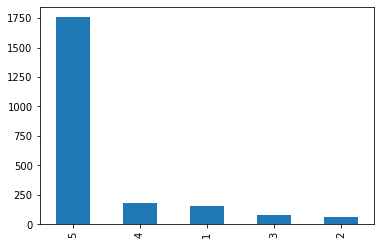

In [24]:
rating=df_ssdreview['rating_stars'].value_counts().plot(kind='bar')
rating

**Observation: ** The rating is biased and accuracy metrics will not be accurate. The metrics like precision , recall and F1 score should be used to determine the accuracy in this case.

### 4.3 Let's analyze other features like year, month, and day etc.
#### Check value counts of 'year' and write your observations., Comment on the range of years, frequency of ratings in each year.

In [26]:
yr=df_ssdreview['year'].value_counts()
yr

2015    1006
2016     605
2017     370
2018     187
2019      46
2014      13
Name: year, dtype: int64

**Observation:**
The ratings are provided for the timeframe 2014 to 2019.

The first review is provided in 2014 and the latest review provided in 2019.

#### Check mean rating for each year and write your findings

In [29]:
df_ssdreview.groupby("year")["rating_stars"].mean()

year
2014   4.9230769
2015   4.4582505
2016   4.5900826
2017   4.5108108
2018   4.3475936
2019   4.3478261
Name: rating_stars, dtype: float64

#### Check value counts of 'month' and write your observations. Comment on the frequency of ratings and discuss if the rating count and mean rating is higher/low on certain months.

In [34]:
mnth=df_ssdreview['month'].value_counts()
mnth

12    278
2     239
3     234
1     221
4     205
11    191
5     158
9     157
7     144
10    141
6     140
8     119
Name: month, dtype: int64

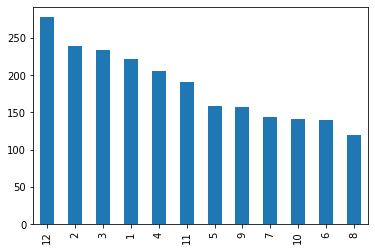

In [35]:
mnth.plot(kind='bar')

In [38]:
df_ssdreview.groupby("month")["rating_stars"].mean()

month
1    4.6425339
2    4.4058577
3    4.6111111
4    4.4195122
5    4.4493671
6    4.5571429
7    4.7638889
8    4.4789916
9    4.5414013
10   4.3049645
11   4.4607330
12   4.3597122
Name: rating_stars, dtype: float64

**Observation:**


Across the year 2014-2019, July month has highest customer rating and October month has the lowest customer rating. 

Although the December month has high number of reviews, the ratings are lowest compared to other months.


### 4.4 Combine text features
#### Drop all the numerical features ['Unnamed: 0','date', 'year', 'month', 'day', 'ownership_pariod'] and ['rating_stars']

In [40]:
NUMERIC_COLUMNS = ['Unnamed: 0','date', 'year', 'month', 'day', 'ownership_pariod']
LABELS = ['rating_stars']
to_drop = NUMERIC_COLUMNS + LABELS
text_data = df_ssdreview.drop(to_drop, axis=1)

In [41]:
text_data.head()

,review_title,overall_review,pros,cons
0,solid,buy it you will not regret this purchase,reliable fast silent cool running drive highly...,NaN
1,nice drive for price even cheaper by todays costs,good drive price,been running almost constantly since when i pu...,NaN
2,perfect,used this drive as my boot drive and only data...,good value decently fast good longevity,none so far
3,very snappy,os boots quicker os menus pop up quicker gamin...,noticeable improvement in os performance over ...,samsung magician software causes some games to...
4,worth the hype,this was the sdd that everyone said to get and...,NaN,NaN


#### Replace null values (NaN) with blanks

In [42]:
text_data.isna().sum()

review_title       96
overall_review    779
pros               22
cons               11
dtype: int64

In [44]:
text_data.fillna(" ", inplace=True)

In [45]:
text_data.isna().sum()

review_title      0
overall_review    0
pros              0
cons              0
dtype: int64

In [46]:
text_data.head()

,review_title,overall_review,pros,cons
0,solid,buy it you will not regret this purchase,reliable fast silent cool running drive highly...,
1,nice drive for price even cheaper by todays costs,good drive price,been running almost constantly since when i pu...,
2,perfect,used this drive as my boot drive and only data...,good value decently fast good longevity,none so far
3,very snappy,os boots quicker os menus pop up quicker gamin...,noticeable improvement in os performance over ...,samsung magician software causes some games to...
4,worth the hype,this was the sdd that everyone said to get and...,,


#### Join all text items in a row that have a space in between and Add a new column (with the newly created combined reviews) to the dataframe.

In [49]:
data_transf=text_data.apply(lambda x: " ".join(x), axis=1)

In [50]:
data_transf.head(5)

0    solid buy it you will not regret this purchase...
1    nice drive for price even cheaper by todays co...
2    perfect used this drive as my boot drive and o...
3    very snappy os boots quicker os menus pop up q...
4    worth the hype this was the sdd that everyone ...
dtype: object

In [52]:
df_final=pd.DataFrame(data_transf, columns=['combined_reviews'])
df_final.head()

,combined_reviews
0,solid buy it you will not regret this purchase...
1,nice drive for price even cheaper by todays co...
2,perfect used this drive as my boot drive and o...
3,very snappy os boots quicker os menus pop up q...
4,worth the hype this was the sdd that everyone ...


In [53]:
df_final['ratings']=df_ssdreview['rating_stars']

In [54]:
df_final.head()

,combined_reviews,ratings
0,solid buy it you will not regret this purchase...,5
1,nice drive for price even cheaper by todays co...,5
2,perfect used this drive as my boot drive and o...,5
3,very snappy os boots quicker os menus pop up q...,5
4,worth the hype this was the sdd that everyone ...,5


#### Check if there are any null values and drop NaN values if any

In [55]:
df_final.isna().sum()

combined_reviews    0
ratings             0
dtype: int64

There is no null values in the final dataset

#### Calculate the length of each review and add it to the dataframe

In [61]:
df_final['len']=df_final['combined_reviews'].apply(lambda x:len(x.split(" ")))

In [62]:
df_final.head(5)

,combined_reviews,ratings,len
0,solid buy it you will not regret this purchase...,5,19
1,nice drive for price even cheaper by todays co...,5,42
2,perfect used this drive as my boot drive and o...,5,65
3,very snappy os boots quicker os menus pop up q...,5,42
4,worth the hype this was the sdd that everyone ...,5,32


#### Check summary stats of the length column

In [63]:
df_final.describe()

,ratings,len
count,2227.0000000,2227.0000000
mean,4.4939380,85.2752582
std,1.1427077,87.3063671
min,1.0000000,6.0000000
25%,5.0000000,31.0000000
50%,5.0000000,60.0000000
75%,5.0000000,109.0000000
max,5.0000000,1615.0000000


### 4.5 Analyzing and preparing the text data


#### Set the max length of each review to 25 since it results in faster training (however, you are free to change this)
#### Set max_features to 10000 and embedding size to 50

In [64]:
max_features = 10000
maxlen = 25
embedding_size = 50

#### Tokenize the cobined text data. You can use the Tokenizer from tensorflow.keras.preprocessing.text. Check the number of samples post tokenization.

In [67]:
tokenizer=Tokenizer(num_words=max_features)

In [93]:
#tokenizer.fit_on_texts(list(df_final['combined_reviews']))  # take all 10K top words and assign a unique number.
tokenizer.fit_on_texts(df_final['combined_reviews'].tolist())
X=tokenizer.texts_to_sequences(df_final['combined_reviews']) #map the index value to the text.

In [94]:
#Number of samples post tokenization
len(tokenizer.word_index)

8838

In [95]:
len(X)

2227

#### Pad the above tokenized reviews data save it as independent features. Use max_len for the same.

In [96]:
X =pad_sequences(X, maxlen=maxlen)
y=np.asarray(df_final['ratings'])

#### Check the shape of X (padded tokenized review data) and y (rating_stars) data.

In [97]:
print(len(X[0]))
print(len(X[1]))

25
25


In [98]:
print(len(y))

2227


#### Check the total number of words in the dictionary (of tekenizer)

In [99]:
num_words=len(tokenizer.word_index)+1
num_words

8839

### 4.6 Compute the glove embeddings. Use the provided txt file for the same.

#### Read the glove embeddings from the file provided titled ‘glove.6B.50d.txt’. And save it to a dictotionary having word and corresponding embedding vector.

In [100]:
EMBEDDING_FILE='/content/drive/MyDrive/Colab Notebooks/R9-Sequence Model NLP/LAB/glove.6B.50d.txt'

In [102]:
embeddings={}
for o in open(EMBEDDING_FILE):
  word=o.split(" ")[0]
  #print(word)
  embd=o.split(" ")[1:]
  embd=np.asarray(embd, dtype='float32')
  #print(embd)
  embeddings[word]=embd

In [103]:
len(embeddings)

400000

#### Create a weight matrix for words in the training docs

In [104]:
embedding_matrix = np.zeros((num_words, 50))

for word, i in tokenizer.word_index.items():
  embedding_vector = embeddings.get(word)
  if embedding_vector is not None:
    embedding_matrix[i] = embedding_vector 

#### Check length of the embedding

In [105]:
len(embeddings)

400000

### 4.7 Target Feature:- One hot encode the target variable (rating_stars)

In [109]:
enc=OneHotEncoder()
y_encoded=enc.fit_transform(y.reshape(-1,1))
y_encoded

<2227x5 sparse matrix of type '<class 'numpy.float64'>'
	with 2227 stored elements in Compressed Sparse Row format>

In [110]:
# from tensorflow.keras.utils import to_categorical

# y_en=to_categorical(y, num_classes=6)
# y_en

#Another way of encoding the target variable

array([[0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       ...,
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.]], dtype=float32)

In [111]:
y

array([5, 5, 5, ..., 5, 5, 5])

In [112]:
set(y)

{1, 2, 3, 4, 5}

In [113]:
y_encoded=y_encoded.todense()
y_encoded

matrix([[0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        ...,
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.]])

### 4.8 Split the data into Train & Test sets

In [115]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, random_state = 50, stratify=y_encoded, test_size=0.3)

## 5. Model building

### 5.1 Construct a neural network architecture using embedding and LSTM layers for building the rating prediction model.
- Use the num_words, embedding_size from the above tokenizer and embeddings respectively
- Use weights from the above embedding matrix
- Use input length as the maxlen
- Add LSTM layers

In [117]:
tf.keras.backend.clear_session() 
model = Sequential()

model.add(Embedding(input_dim=num_words, 
                    output_dim=embedding_size, 
                    weights = [embedding_matrix], 
                    input_length=maxlen))

model.add(LSTM(128, return_sequences = True))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(256, activation = 'relu'))
model.add(Dense(128, activation = 'relu'))
model.add(Dense(64, activation= 'relu'))
model.add(Dropout(0.5))
model.add(Dense(5, activation="softmax"))


In [119]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 25, 50)            441950    
_________________________________________________________________
lstm (LSTM)                  (None, 25, 128)           91648     
_________________________________________________________________
flatten (Flatten)            (None, 3200)              0         
_________________________________________________________________
dense (Dense)                (None, 512)               1638912   
_________________________________________________________________
dense_1 (Dense)              (None, 256)               131328    
_________________________________________________________________
dense_2 (Dense)              (None, 128)               32896     
_________________________________________________________________
dense_3 (Dense)              (None, 64)                8

### 5.2 Compile the model using appropriate loss, optimizer, and accuracy metric

In [128]:
#Adam optimizer with learning rate - .0001
#adam =optimizers.Adam(lr = 0.0001)

#compile the model
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

### 5.3 Fit the model

In [139]:
batch_size = 100
epochs = 5

history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_test, y_test))


Epoch 1/5
16/16 [==============================] - 2s 148ms/step - loss: 0.5422 - accuracy: 0.8068 - val_loss: 0.7305 - val_accuracy: 0.7683
Epoch 2/5
16/16 [==============================] - 2s 144ms/step - loss: 0.4792 - accuracy: 0.8280 - val_loss: 0.7635 - val_accuracy: 0.7818
Epoch 3/5
16/16 [==============================] - 2s 142ms/step - loss: 0.3767 - accuracy: 0.8678 - val_loss: 0.9541 - val_accuracy: 0.7937
Epoch 4/5
16/16 [==============================] - 2s 144ms/step - loss: 0.2940 - accuracy: 0.8960 - val_loss: 1.0906 - val_accuracy: 0.7265
Epoch 5/5
16/16 [==============================] - 2s 136ms/step - loss: 0.2552 - accuracy: 0.9095 - val_loss: 1.0723 - val_accuracy: 0.7489


In [140]:
results = model.evaluate(X_test, y_test)

21/21 [==============================] - 0s 17ms/step - loss: 1.0723 - accuracy: 0.7489


### 5.4 Predict ratings for test data and check accuracy and confusion matrix

In [141]:
predictions = model.predict(X_test.reshape(len(X_test),25))

y_test_inv = enc.inverse_transform(y_test)

y_pred_inv = enc.inverse_transform(np.around(predictions))

In [137]:
print(y_test_inv.shape)
print(y_pred_inv.shape)

(669, 1)
(669, 1)


In [149]:
print("Accuracy score:", accuracy_score(y_test_inv, y_pred_inv))

Accuracy score: 0.7399103139013453


In [146]:
print(classification_report(y_test_inv, y_pred_inv))

              precision    recall  f1-score   support

           1       0.30      0.74      0.42        46
           2       0.00      0.00      0.00        18
           3       0.00      0.00      0.00        23
           4       0.19      0.15      0.17        54
           5       0.88      0.86      0.87       528

    accuracy                           0.74       669
   macro avg       0.27      0.35      0.29       669
weighted avg       0.73      0.74      0.73       669



### 5.5 Display plot of training and validation loss/accuracy wrt to epochs

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


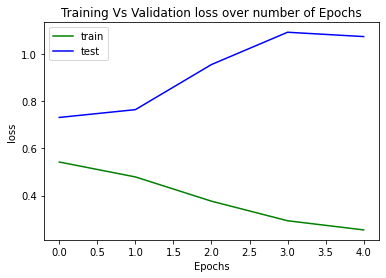

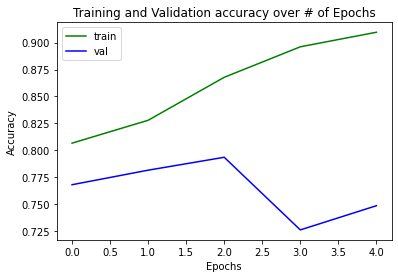

In [142]:
# list all data in history
print(history.history.keys())

# summarize history for loss
plt.plot(history.history['loss'],'g', label='Training loss' )
plt.plot(history.history['val_loss'], 'b', label='Validation loss')
plt.title('Training Vs Validation loss over number of Epochs')
plt.ylabel('loss')
plt.xlabel('Epochs')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for accuracy
plt.plot(history.history['accuracy'], 'g', label='Training accuracy')
plt.plot(history.history['val_accuracy'], 'b', label='validation accuracy')
plt.title('Training and Validation accuracy over # of Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

## 6. Conclusion and Interpretation

In [ ]:
The dataset is imbalanced as the overall rating '5' is high in mumber than other ratings and hence the macro avg is 29%
Due to the imbalanced dataset, there is a overfit.
Although the overall accuracy is 74%, due to imbalanced dataset - the prediction of other classes are not accurate as rating '5'.

## 7. Food for thought:

1.) Change activation function (try leaky_relu or tanh) and see if it helps in improving model performance with the dataset that is highly imbalanced

2.) Try with only the overall review feature and see if it leads to improvement in model performace

3.) Change the hyperparameters of the model and compare the results 

In [159]:
tf.keras.backend.clear_session() 
model1 = Sequential()

model1.add(Embedding(input_dim=num_words, 
                    output_dim=embedding_size, 
                    weights = [embedding_matrix], 
                    input_length=maxlen))

model1.add(LSTM(128, return_sequences = True))
model1.add(Flatten())
model1.add(Dense(512, activation='tanh'))
model1.add(tf.keras.layers.BatchNormalization())
model1.add(Dense(256, activation = 'tanh'))
model1.add(tf.keras.layers.BatchNormalization())
model1.add(Dense(128, activation = 'tanh'))
model1.add(tf.keras.layers.BatchNormalization())
model1.add(Dense(64, activation= 'tanh'))
model1.add(tf.keras.layers.BatchNormalization())
model1.add(Dropout(0.5))
model1.add(Dense(5, activation="softmax"))

In [160]:
model1.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 25, 50)            441950    
_________________________________________________________________
lstm (LSTM)                  (None, 25, 128)           91648     
_________________________________________________________________
flatten (Flatten)            (None, 3200)              0         
_________________________________________________________________
dense (Dense)                (None, 512)               1638912   
_________________________________________________________________
batch_normalization (BatchNo (None, 512)               2048      
_________________________________________________________________
dense_1 (Dense)              (None, 256)               131328    
_________________________________________________________________
batch_normalization_1 (Batch (None, 256)               1

In [161]:
model1.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [162]:
batch_size = 100
epochs = 20

history = model1.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_test, y_test))


Epoch 1/20
16/16 [==============================] - 6s 189ms/step - loss: 2.2762 - accuracy: 0.2651 - val_loss: 1.7177 - val_accuracy: 0.1943
Epoch 2/20
16/16 [==============================] - 2s 148ms/step - loss: 1.7944 - accuracy: 0.3748 - val_loss: 1.2769 - val_accuracy: 0.7160
Epoch 3/20
16/16 [==============================] - 2s 149ms/step - loss: 1.5276 - accuracy: 0.4506 - val_loss: 1.4129 - val_accuracy: 0.5067
Epoch 4/20
16/16 [==============================] - 2s 148ms/step - loss: 1.3376 - accuracy: 0.5051 - val_loss: 1.4324 - val_accuracy: 0.4873
Epoch 5/20
16/16 [==============================] - 2s 146ms/step - loss: 1.1933 - accuracy: 0.5860 - val_loss: 1.1358 - val_accuracy: 0.6741
Epoch 6/20
16/16 [==============================] - 2s 147ms/step - loss: 1.0085 - accuracy: 0.6476 - val_loss: 0.9215 - val_accuracy: 0.7280
Epoch 7/20
16/16 [==============================] - 2s 149ms/step - loss: 0.8696 - accuracy: 0.6996 - val_loss: 0.8565 - val_accuracy: 0.7713
Epoch 

In [156]:
results = model1.evaluate(X_test, y_test)

21/21 [==============================] - 0s 15ms/step - loss: 1.2900 - accuracy: 0.7818


In [157]:
predictions = model1.predict(X_test.reshape(len(X_test),25))

y_test_inv = enc.inverse_transform(y_test)

y_pred_inv = enc.inverse_transform(np.around(predictions))

In [158]:
print(classification_report(y_test_inv, y_pred_inv))

              precision    recall  f1-score   support

           1       0.61      0.43      0.51        46
           2       0.22      0.11      0.15        18
           3       0.21      0.13      0.16        23
           4       0.19      0.19      0.19        54
           5       0.88      0.93      0.90       528

    accuracy                           0.78       669
   macro avg       0.42      0.36      0.38       669
weighted avg       0.76      0.78      0.77       669

